In [1]:
import numpy as np
import matplotlib.pyplot as plt

import baccoemu

%matplotlib inline
from classy import Class
from scipy.optimize import fsolve
from scipy.interpolate import interp1d

import jax
jax.config.update("jax_enable_x64", True) 
import jax.numpy as jnp
from discoeb.background import evolve_background
from discoeb.perturbations import evolve_perturbations, get_power, evolve_perturbations_batched

import os 
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


## Cosmological Parameters
Tcmb    = 2.7255
YHe     = 0.248
Omegam  = 0.3099
Omegab  = 0.0488911
Omegac  = Omegam - Omegab
Omegak  = 0 
w_DE_0  = -0.99
w_DE_a  = 0.0
cs2_DE  = 1.0
# Initialize neutrinos.
num_massive_neutrinos = 1
mnu     = 0.06  #eV
Tnu     = (4/11)**(1/3) #0.71611 # Tncdm of CLASS
Neff    = 3.046 # -1 if massive neutrino present
N_nu_mass = 1
N_nu_rel = Neff - N_nu_mass * (Tnu/((4/11)**(1/3)))**4
h       = 0.67742
A_s     = 2.1064e-09
n_s     = 0.96822
k_p     = 0.05

# modes to sample
nmodes = 512
kmin = 1e-5
kmax = 1e+2 # 1e+1
aexp = 0.01

/home/raphael/venv/discodj_env/lib/python3.12/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


# BACCO

Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator Burger et al. (2025)...
/home/raphael/venv/discodj_env/lib/python3.12/site-packages/baccoemu/bispectrum_baryonic_boost/powerspectra_ratio_bcm_emu_folded.pkl
dict_keys(['n_parameters', 'parameters', 'feature_dimensions', 'scaling_division', 'scaling_subtraction', 'parameter_ranges', 'weights', 'hyper_params', 'param_train_mean', 'param_train_std', 'feature_train_mean', 'feature_train_std'])
Baryonic Emulator for matter powerspectrum Burger et al. (2025) loaded in memory.
2.65e-09 0.15 0.7833669902941891
2.65e-09 0.3 0.7559346635209598


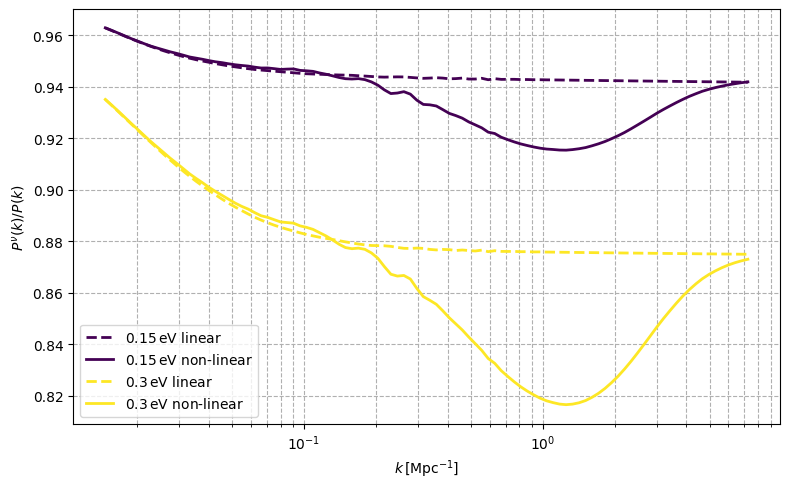

In [7]:

params = {
    'omega_cold': 0.3099 - 0.0488911,
    'omega_baryon': 0.0488911,
    'hubble': 0.67742,
    'ns': 0.96822,
    'neutrino_mass':0,
    # augmenté
    'A_s': 2.65e-09,

    'neutrino_mass': 0.0,
    'w0': -0.99,
    'wa': 0,
    'expfactor': 1
}

emulator = baccoemu.Matter_powerspectrum(baryonic_model_name='Burger2025')

k = np.logspace(-2, np.log10(4.9), 100)

k_ref, pk_ref = emulator.get_linear_pk(k=k,cold=True,**params)

sigma8_ref = emulator.get_sigma8(cold=True,**params)

params_nl_ref = params.copy()
params_nl_ref.pop('A_s')
params_nl_ref['sigma8_cold'] = sigma8_ref

k_nl_ref, pk_nl_ref = emulator.get_nonlinear_pk(
    k=k,
    cold=True,
    allow_extrapolation=True,
    **params_nl_ref
)

results_bacco = []
results_bacco_nl = []

masses = [0.15, 0.3]

colors = plt.cm.viridis(np.linspace(0,1,len(masses)))

plt.figure(figsize=(8,5))

for mass, color in zip(masses, colors):

    pars = params.copy()

    pars['neutrino_mass'] = mass
    omega_nu = mass / (93.14 * pars['hubble']**2)

    #pars['omega_cold'] = (
    #    0.3099 - 0.0488911 - omega_nu
    #)


    k_lin, pk_lin = emulator.get_linear_pk(
        k=k,
        cold=True,
        **pars
    )

    ratio_lin = pk_lin / pk_ref

    sigma8 = emulator.get_sigma8(cold=True,**pars)

    pars_nl = pars.copy()

    pars_nl['sigma8_cold'] = sigma8
    print(pars_nl['A_s'],mass,sigma8)
    pars_nl.pop('A_s')

    k_nl, pk_nl = emulator.get_nonlinear_pk(
        k=k,
        cold=True,
        allow_extrapolation=True,
        **pars_nl
    )

    ratio_nl = pk_nl / pk_nl_ref

    results_bacco.append({
        "k": k_lin/0.67742,
        "ratio": ratio_lin,
        "mass": mass,
        "method": "BACCO"
    })

    results_bacco_nl.append({
        "k": k_nl/0.67742,
        "ratio": ratio_nl,
        "mass": mass,
        "method": "BACCO_NL"
    })

    plt.semilogx(
        k_lin/0.67742 ,
        ratio_lin,
        '--',
        color=color,
        linewidth=2,
        label=fr'${mass}\,\mathrm{{eV}}$ linear'
    )

    plt.semilogx(
        k_nl/0.67742 ,
        ratio_nl,
        '-',
        color=color,
        linewidth=2,
        label=fr'${mass}\,\mathrm{{eV}}$ non-linear'
    )

plt.xlabel(r'$k\,[\mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P^\nu(k)/P(k)$')

plt.grid(True, which='both', ls='--')

plt.legend()

plt.tight_layout()
plt.show()
np.save("bacco_results.npy", results_bacco)
np.save("bacco_results_nl.npy", results_bacco_nl)

# CLASS

In [2]:
def get_class_power( fieldname, zout ):
  tk, k, z = cosmo_massless.get_transfer_and_k_and_z()
  TT = interp1d( np.log(1/(1+z)), tk[fieldname], axis=1 )( np.log(1/(1+zout)) ) 
  #res =  2*np.pi**2*A_s*(k/k_p*h)**(n_s - 1) * k**(-3) * TT**2 
  res =  2*np.pi**2*A_s*(k/k_p)**(n_s - 1) * k**(-3) * TT**2
  return res, k

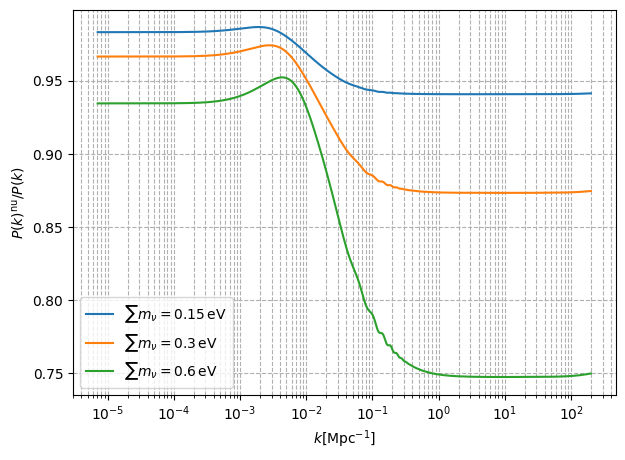

In [ ]:
common_settings = {'output': 'mPk'}
zout = 0.0
h = 0.67742
k = np.logspace(-4, 1, 300)

pk_cb_massless = []
pk_cb_massive = []

plt.figure(figsize=(7,5))

cosmo_massless = Class()

params_massless = common_settings.copy()
params_massless.update({
    'Omega_k': 0.0,
    'Omega_b': Omegab,
    'Omega_cdm': Omegac,
    'h': h,
    'A_s': A_s,
    'n_s': n_s,
    'gauge': 'synchronous',
    'reio_parametrization': 'reio_none',
    'k_per_decade_for_pk': 100,
    'k_per_decade_for_bao': 100,
    'T_cmb': Tcmb,
    'YHe': YHe,
    'output': 'mPk,mTk,vTk',
    'P_k_max_1/Mpc': 2 * kmax,
    'z_max_pk': 1000.0,
    'recombination': 'RECFAST',
    'l_max_g': 31,
    'l_max_pol_g': 31,
    'l_max_ur': 31,
    'l_max_ncdm': 31,
    'Omega_Lambda': 0.0,
    'w0_fld': -0.99,
    'wa_fld': 0,
    'cs2_fld': 1.0,
    'use_ppf': 'no',
    'radiation_streaming_approximation': 2,
    'ncdm_fluid_approximation': 3,
    'ur_fluid_approximation': 2,
    'N_ur': 2.046,
    'N_ncdm': 1,
    'm_ncdm': 1e-10
})

cosmo_massless.set(params_massless)
cosmo_massless.compute()
Pknu_CLASS, k_CLASS = get_class_power('d_ncdm[0]', zout)
kmax_used = cosmo_massless.pars['P_k_max_1/Mpc']
mask = k_CLASS <= kmax_used
k_used = k_CLASS[mask]


Pkbc_CLASS = np.array([cosmo_massless.pk_cb(ki, zout) for ki in k_used])

Pkbc_CLASS_hunits = Pkbc_CLASS * h**3

np.savetxt(
    "Pk_cb_massless_z0.txt",
    np.column_stack([k_used, Pkbc_CLASS_hunits]),
    header="k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, massless neutrinos)"
)

results_class = []

for sum_masses in [0.15, 0.3, 0.6]:

    cosmo_massive = Class()
    pk_cb_massive = []

    params_massive = params_massless.copy()
    params_massive.update({
        'Omega_cdm': Omegac,
        'N_ncdm': 1,
        'deg_ncdm': 1,
        'm_ncdm': sum_masses,
        'N_ur': 2.046
    })

    cosmo_massive.set(params_massive)
    cosmo_massive.compute()



    Pkbc_CLASS_nu = np.array([cosmo_massive.pk_cb(ki, zout) for ki in k_used])

    Pkbc_CLASS_hunits = Pkbc_CLASS_nu * h**3
    fname = f"Pk_cb_sumMnu_{sum_masses:.2f}eV_z0.txt"

    np.savetxt(
        fname,
        np.column_stack([k_used, Pkbc_CLASS_hunits]),
        header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, sum m_nu = {sum_masses} eV)"
    )


    ratio = Pkbc_CLASS_nu / Pkbc_CLASS

    plt.semilogx(
        k_used,
        ratio,
        label=rf'$\sum m_\nu = {sum_masses}\,\mathrm{{eV}}$'
    )

    results_class.append({
        "k": k_used,
        "ratio": ratio,
        "mass": sum_masses,
        "method": "CLASS"
    })

    cosmo_massive.struct_cleanup()
    cosmo_massive.empty()

plt.xlabel(r'$k [\mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P(k)^\mathrm{nu}/P(k)$')
plt.grid(True, which='both', ls='--')
plt.legend(fontsize=10)
plt.show()

np.save("class_results.npy", results_class)

cosmo_massless.struct_cleanup()
cosmo_massless.empty()

# DISCO-EB

<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2455302/2734714319.py:58: SyntaxWarning: invalid escape sequence '\s'
  plt.semilogx(kmodes,Pkm_nu/Pkm, label='$\sum m_i = '+str(sum_masses)+'$eV')


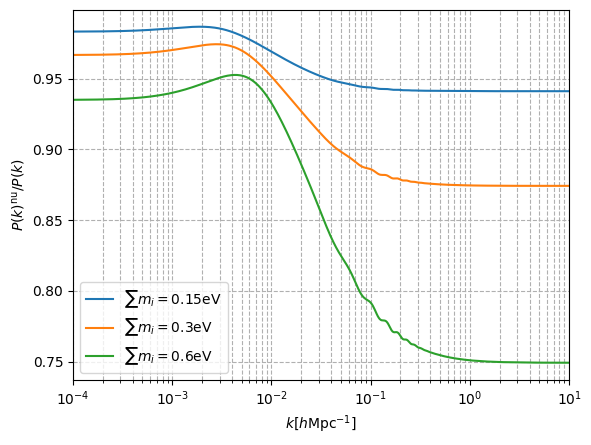

In [ ]:
@jax.jit
def compute_matter_power( Omegam=0.3099, mnu=0.0):

    param = {}
    param['Omegam']  = Omegam            # Total matter density parameter
    param['Omegab']  = Omegab       # Baryon density parameter
    param['w_DE_0']  = w_DE_0              # Dark energy equation of state parameter today
    param['w_DE_a']  = w_DE_a               # Dark energy equation of state parameter time derivative
    param['cs2_DE']  = cs2_DE               # Dark energy sound speed squared
    param['Omegak']  = Omegak
    param['A_s']     = A_s                # Scalar amplitude of the primordial power spectrum
    param['n_s']     = n_s        # Scalar spectral index
    param['H0']      = h*100           # Hubble constant today in units of 100 km/s/Mpc
    param['Tcmb']    = Tcmb          # CMB temperature today in K
    param['YHe']     = YHe             # Helium mass fraction
    param['Neff']    = 2.046             # Effective number of ultrarelativistic neutrinos
                                        # -1 if massive neutrino present
    param['Nmnu']    = 1                 # Number of massive neutrinos (must be 1 currently)
    param['mnu']     = mnu              # Sum of neutrino masses in eV 
    param['k_p']     =  k_p             # Pivot scale in 1/Mpc
    # modes to sample
    nmodes = 512                         # number of modes to sample
    kmin   = 1e-4                        # minimum k in 1/Mpc
    kmax   = 10                          # maximum k in 1/Mpc
    aexp   = 1.0                         # scale factor at which to evaluate the power spectrum
    
    
    param = evolve_background(param=param, thermo_module='RECFAST')

    aexp_out = jnp.array([aexp])

    y, kmodes = evolve_perturbations_batched( param=param, kmin=kmin, kmax=kmax, num_k=nmodes, aexp_out=aexp_out,
                                    lmaxg = 31, lmaxgp = 31, lmaxr = 31, lmaxnu = 31, nqmax = 5,
                                    max_steps=32768,
                                    rtol=1e-5, atol=1e-5, batch_size=32 )
 
    iout = -1
    fac = 2 * np.pi**2 * A_s
    Pkbc = fac *(kmodes/k_p)**(n_s - 1) * kmodes**(-3) * y[:,iout,6]**2

    return Pkbc, kmodes

Omegam_fid = 0.3099
results_disco = []
h=0.67742
Pkm, kmodes = compute_matter_power( Omegam_fid,0 )

for sum_masses in [0.15, 0.3, 0.6]:
    Pkm_nu, kmodes_nu = compute_matter_power( Omegam_fid,sum_masses )

    results_disco.append({
        "k": kmodes,
        "ratio": Pkm_nu / Pkm,
        "mass": sum_masses,
        "method": "DISCOEB"
    })

    plt.semilogx(kmodes,Pkm_nu/Pkm, label='$\sum m_i = '+str(sum_masses)+'$eV')
plt.xlim(kmodes[0],kmodes[-1])
plt.xlabel(r'$k [\mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P(k)^\mathrm{nu}/P(k)$')  
plt.grid(True, which='both', ls='--')
plt.legend(fontsize=10)

np.save("discoeb_results.npy", results_disco)